# GLIPH-like Multi-family Enrichment and Full-Graph Clustering (TRB)

This notebook implements a GLIPH-style workflow on TRB clonotypes with expanded token families and a full graph stage:

1. Load `gliph_trb.tsv.gz` from the local benchmark cache.
2. Collapse each study to a unique list of `(v_gene, junction_aa)` clonotypes before token counting.
3. Build five token families per clonotype:
   - **v+3-mer**
   - **pos+3mer**
   - **ungapped 4-mer**
   - **gapped 4-mer**
   - **gapped 5-mer**
4. Compare sample-vs-control **VJ usage** after V-only control normalization to diagnose residual gene-usage drift.
5. For each study and family, run **binomial enrichment** against a V-only matched real TRB control sample of size `1,000,000`.
6. Plot separate volcano plots for each family/study pair, showing only the `enrichment ratio > 1.0` side.
7. Merge all enriched tokens into a heterogeneous graph (token-clonotype edges + clonotype-clonotype Hamming `<= 1` edges).
8. Expand the clonotype set by one Hamming-hop from the current graph.
9. Build one-mode projections (clonotype and k-mer sides), run connected components and Leiden communities, and evaluate concordance against `stimulus` and `gliph_cluster_id`.

The implementation reuses `mir/**` components for token extraction, control normalization, binomial enrichment, and edit-distance graph construction.

In [ ]:
from __future__ import annotations

from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path
import importlib
import re

import igraph as ig
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

import mir.biomarkers.gliph as gliph_mod
importlib.reload(gliph_mod)

from mir.biomarkers.gliph import (
    GliphTokenArtifacts,
    build_full_gliph_clonotype_graph,
    build_kmer_projection_graph,
    combine_enriched_token_maps,
    deduplicate_clonotype_rows,
    extract_g4mer_artifacts,
    extract_g5mer_artifacts,
    extract_pos3mer_artifacts,
    extract_u4mer_artifacts,
    extract_v3mer_artifacts,
    normalize_control_v,
 )
from mir.biomarkers.token_stats import compare_kmer_counts
from mir.common.control import ControlManager
from mir.utils.notebook_assets import ensure_airr_benchmark, find_repo_root


/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Reproducibility & paths ---
import sys
repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('repo_root:', repo_root)

REPO_GLPH_PATH = repo_root / 'airr_benchmark' / 'gliph' / 'gliph_trb.tsv.gz'
NOTEBOOK_GLPH_PATH = repo_root / 'notebooks' / 'assets' / 'large' / 'airr_benchmark' / 'gliph' / 'gliph_trb.tsv.gz'
HF_PATTERN = ['gliph/gliph_trb.tsv.gz']
FORCE_HF_REFRESH = False
CONTROL_LABELS = {'control', 'healthy_control', 'healthy', 'naive', 'unstimulated'}

# --- Analysis parameters ---
CONTROL_SAMPLE = 1_000_000
TOKEN_THREADS = 4
COUNT_MODE = 'clonotype'
KMER_PSEUDOCOUNT = 1
SIG_FDR = 0.05
SIG_ENRICHMENT = 1.0
SIG_ODDS = SIG_ENRICHMENT
TOP_LABELS = 10
MIN_CLUSTER_SIZE = 3
MIN_TOKEN_CLONOTYPES = 2
MAX_GRAPH_NODES = 450
CLONE_EDGE_MIN_WEIGHT = 0.35
SEED = 42

FAMILIES = ['v3', 'pos3', 'u4', 'g4', 'g5']
FAMILY_LABELS = {
    'v3': 'V+3-mer',
    'pos3': 'pos+3mer',
    'u4': 'Ungapped 4-mer',
    'g4': 'Gapped 4-mer',
    'g5': 'Gapped 5-mer',
}
FAMILY_COLORS = {
    'v3': '#e76f51',
    'pos3': '#f4a261',
    'u4': '#2a9d8f',
    'g4': '#457b9d',
    'g5': '#6d597a',
}
STIMULUS_PALETTE = {
    'MegaIL2': '#d62828',
    'CMV': '#003049',
    'EBV': '#6a994e',
    'YellowFever': '#ffb703',
    'influenza': '#8ecae6',
}
CLUSTER_METHODS = ['components', 'leiden']
STUDY_KEYWORDS = {
    'Glanville2017': 'glanville',
    'Huang2020': 'huang',
}

AA_RE = re.compile(r'^[ACDEFGHIKLMNPQRSTVWY]+$')

repo_root: /Users/mikesh/vcs/mirpy


In [3]:
def _pick_col(df: pd.DataFrame, candidates: list[str], required: bool = True) -> str | None:
    existing = {c.lower(): c for c in df.columns}
    for c in candidates:
        got = existing.get(c.lower())
        if got is not None:
            return got
    if required:
        raise KeyError(f'Missing required column. Tried: {candidates}. Available: {list(df.columns)}')
    return None


def _resolve_gliph_path(force_hf_refresh: bool = FORCE_HF_REFRESH) -> Path:
    if REPO_GLPH_PATH.exists() and not force_hf_refresh:
        return REPO_GLPH_PATH
    if NOTEBOOK_GLPH_PATH.exists() and not force_hf_refresh:
        return NOTEBOOK_GLPH_PATH
    ds_root = ensure_airr_benchmark(repo_root=repo_root, allow_patterns=HF_PATTERN)
    path = ds_root / 'gliph' / 'gliph_trb.tsv.gz'
    if not path.exists():
        raise FileNotFoundError(f'Could not find gliph_trb.tsv.gz at {path}')
    return path


def _normalize_df(raw: pd.DataFrame) -> pd.DataFrame:
    c_seq = _pick_col(raw, ['junction_aa', 'cdr3aa', 'cdr3'])
    c_v = _pick_col(raw, ['v_gene', 'v', 'v.segm'])
    c_j = _pick_col(raw, ['j_gene', 'j', 'j.segm'], required=False)
    c_dc = _pick_col(raw, ['duplicate_count', 'count', 'read.count'], required=False)
    c_study = _pick_col(raw, ['reference_id', 'study_id', 'study'])
    c_donor = _pick_col(raw, ['donor_id', 'donor', 'subject_id'], required=False)
    c_stim = _pick_col(raw, ['stimulus', 'status', 'condition'])
    c_ep = _pick_col(raw, ['epitope', 'antigen.epitope'], required=False)
    c_gliph = _pick_col(raw, ['gliph_cluster_id', 'cluster_id'], required=False)

    out = pd.DataFrame({
        'junction_aa': raw[c_seq].astype(str).str.strip(),
        'v_gene': raw[c_v].astype(str).str.strip(),
        'j_gene': raw[c_j].astype(str).str.strip() if c_j else '',
        'duplicate_count': pd.to_numeric(raw[c_dc], errors='coerce').fillna(1).astype(int) if c_dc else 1,
        'reference_id': raw[c_study].astype(str).str.strip(),
        'donor_id': raw[c_donor].astype(str).str.strip() if c_donor else 'unknown',
        'stimulus': raw[c_stim].astype(str).str.strip(),
        'epitope': raw[c_ep].astype(str).str.strip() if c_ep else '',
        'gliph_cluster_id': raw[c_gliph].astype(str).str.strip() if c_gliph else '',
    })
    out = out[out['junction_aa'].str.len() >= 5].copy()
    out = out[out['junction_aa'].str.match(AA_RE)].copy()
    out['v_base'] = out['v_gene'].str.split('*').str[0]
    out['is_control'] = out['stimulus'].str.lower().isin(CONTROL_LABELS)
    out = out.reset_index(drop=True)
    out['row_id'] = out.index.astype(str)
    return out


def _deduplicate_gliph_df(df_in: pd.DataFrame) -> pd.DataFrame:
    dedup = deduplicate_clonotype_rows(
        df_in,
        subset=('reference_id', 'junction_aa', 'v_gene'),
    )
    dedup['v_base'] = dedup['v_gene'].astype(str).str.split('*').str[0]
    dedup['is_control'] = dedup['stimulus'].astype(str).str.lower().isin(CONTROL_LABELS)
    return dedup


def _duplicate_summary(df_raw: pd.DataFrame, df_unique: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for study, sdf in df_raw.groupby('reference_id', sort=True):
        unique_sdf = df_unique[df_unique['reference_id'] == study]
        rows.append({
            'reference_id': study,
            'raw_rows': len(sdf),
            'unique_v_junction_clonotypes': len(unique_sdf),
            'removed_duplicates': len(sdf) - len(unique_sdf),
            'with_gliph_cluster_id': int((unique_sdf['gliph_cluster_id'].fillna('').astype(str).str.strip() != '').sum()),
            'with_epitope': int((unique_sdf['epitope'].fillna('').astype(str).str.strip() != '').sum()),
        })
    return pd.DataFrame(rows).sort_values('reference_id').reset_index(drop=True)


In [4]:
gliph_path = _resolve_gliph_path()
raw_df = pd.read_csv(gliph_path, sep='\t', compression='infer')
df_raw = _normalize_df(raw_df)
df = _deduplicate_gliph_df(df_raw)
duplicate_summary = _duplicate_summary(df_raw, df)

print(f'Loaded {len(raw_df):,} raw rows from {gliph_path}')
print(f'Using {len(df):,} unique clonotypes for token counting and clustering')
print('Columns in raw GLIPH table:', ', '.join(raw_df.columns))
display(duplicate_summary)
display(df.head(3))

Loaded 17,936 raw rows from /Users/mikesh/vcs/mirpy/airr_benchmark/gliph/gliph_trb.tsv.gz
Using 13,862 unique clonotypes for token counting and clustering
Columns in raw GLIPH table: junction_aa, v_gene, j_gene, donor_id, duplicate_count, locus, reference_id, stimulus, epitope, gliph_cluster_id


,reference_id,raw_rows,unique_v_junction_clonotypes,removed_duplicates,with_gliph_cluster_id,with_epitope
0,Glanville2017,7433,3928,3505,1287,0
1,Huang2020,10501,9934,567,4493,0


,reference_id,junction_aa,v_gene,j_gene,duplicate_count,donor_id,stimulus,epitope,gliph_cluster_id,v_base,is_control,row_id
0,Glanville2017,CASSPNGIMNTEAFF,TRBV7-6,TRBJ1-1,50835,09/0018,MegaIL2,None,C3282,TRBV7-6,False,0
1,Glanville2017,CASTQSGGTNEKLFF,TRBV28,TRBJ1-4,110298,09/0018,MegaIL2,None,C3374,TRBV28,False,1
2,Glanville2017,CASSAWDRGRFTEAFF,TRBV25-1,TRBJ1-1,91536,09/0018,MegaIL2,None,C626,TRBV25-1,False,2


In [6]:
# Load the real human TRB control repertoire from mir's built-in control cache.
ctrl_manager = ControlManager()
print('Loading real human TRB control (downloads on first run)...')
ctrl_raw = ctrl_manager.ensure_and_load_control_df('real', 'human', 'TRB')
print(f'Full control: {len(ctrl_raw):,} rows   columns: {list(ctrl_raw.columns[:5])}')

ctrl_all = pd.DataFrame({
    'junction_aa': ctrl_raw['junction_aa'].astype(str).str.strip(),
    'v_gene': ctrl_raw['v_gene'].astype(str).str.strip(),
    'j_gene': ctrl_raw['j_gene'].astype(str).str.strip(),
    'duplicate_count': pd.to_numeric(ctrl_raw.get('duplicate_count', 1), errors='coerce').fillna(1).astype(int),
    'stimulus': 'control',
    'reference_id': 'control',
    'epitope': '',
    'gliph_cluster_id': '',
})
ctrl_all = ctrl_all[
    ctrl_all['junction_aa'].str.match(AA_RE)
    & (ctrl_all['junction_aa'].str.len() >= 5)
].copy()

ctrl_by_study: dict[str, pd.DataFrame] = {}
for study, sdf in df.groupby('reference_id', sort=True):
    print(f'\nNormalising control V usage to {study} ({len(sdf):,} unique V+junction clonotypes)...')
    ctrl_norm = normalize_control_v(sdf, ctrl_all, n=CONTROL_SAMPLE, seed=SEED)
    ctrl_by_study[str(study)] = ctrl_norm
    print(f'  -> {len(ctrl_norm):,} control clonotypes (duplicate_count=1, V-matched)')

display(ctrl_by_study[next(iter(ctrl_by_study))].head(3))

# Compare sample/control VJ usage to diagnose why many k-mers can look enriched.
def _base_gene_column(frame: pd.DataFrame, col_name: str) -> pd.Series:
    col = frame[col_name]
    if isinstance(col, pd.DataFrame):
        col = col.iloc[:, 0]
    return col.fillna('').astype(str).str.split('*').str[0]


def _vj_distribution(frame: pd.DataFrame) -> pd.Series:
    v = _base_gene_column(frame, 'v_gene')
    j = _base_gene_column(frame, 'j_gene')
    key = v + '|' + j
    return key.value_counts(normalize=True)


def _tv_distance(sample_dist: pd.Series, control_dist: pd.Series) -> float:
    all_idx = sample_dist.index.union(control_dist.index)
    s = sample_dist.reindex(all_idx, fill_value=0.0)
    c = control_dist.reindex(all_idx, fill_value=0.0)
    return float(0.5 * np.abs(s - c).sum())


vj_drift_rows: list[dict[str, object]] = []
for study, sdf in df.groupby('reference_id', sort=True):
    study = str(study)
    ctrl_df = ctrl_by_study[study]
    sample_v = _base_gene_column(sdf, 'v_gene').value_counts(normalize=True)
    ctrl_v = _base_gene_column(ctrl_df, 'v_gene').value_counts(normalize=True)
    sample_vj = _vj_distribution(sdf)
    ctrl_vj = _vj_distribution(ctrl_df)

    tv_v = _tv_distance(sample_v, ctrl_v)
    tv_vj = _tv_distance(sample_vj, ctrl_vj)
    top_vj_gap = (
        (sample_vj - ctrl_vj.reindex(sample_vj.index, fill_value=0.0))
        .sort_values(ascending=False)
        .head(5)
    )
    vj_drift_rows.append({
        'reference_id': study,
        'tv_distance_v': tv_v,
        'tv_distance_vj': tv_vj,
        'n_sample_vj': int(sample_vj.size),
        'n_control_vj': int(ctrl_vj.size),
        'top_sample_vj_excess': '; '.join(f'{idx}:{val:.4f}' for idx, val in top_vj_gap.items()),
    })

vj_drift_df = pd.DataFrame(vj_drift_rows).sort_values('reference_id').reset_index(drop=True)
print('Sample-vs-control usage drift (after V-only matching):')
display(vj_drift_df)

print('Why many enriched k-mers can appear:')
print('- V-only matching can leave substantial residual VJ drift, so sequence motifs coupled to specific J genes remain overrepresented.')
print('- Overlapping k-mers are highly correlated: one clonotype contributes multiple related tokens, inflating discoveries across families.')
print('- Large control size gives high power, so tiny but systematic composition differences become statistically significant.')

Loading real human TRB control (downloads on first run)...
Full control: 28,257,621 rows   columns: ['duplicate_count', 'junction', 'junction_aa', 'v_gene', 'j_gene']

Normalising control V usage to Glanville2017 (3,928 unique V+junction clonotypes)...
  -> 1,000,000 control clonotypes (duplicate_count=1, V-matched)

Normalising control V usage to Huang2020 (9,934 unique V+junction clonotypes)...
  -> 1,000,000 control clonotypes (duplicate_count=1, V-matched)


,junction_aa,v_gene,j_gene,duplicate_count,stimulus,reference_id,epitope,gliph_cluster_id,row_id
0,CASSEDKNIQYF,TRBV10-1*01,TRBJ2-4*01,1,control,control,,,ctrl_0
1,CASSESTVGFGETQYF,TRBV10-1*01,TRBJ2-5*01,1,control,control,,,ctrl_1
2,CASSVSGTYNEQFF,TRBV10-1*01,TRBJ2-1*01,1,control,control,,,ctrl_2


Sample-vs-control usage drift (after V-only matching):


,reference_id,tv_distance_v,tv_distance_vj,n_sample_vj,n_control_vj,top_sample_vj_excess
0,Glanville2017,0.069501,0.284232,446,600,TRBV20-1|TRBJ1-1:0.0095; TRBV12-3|TRBJ1-2:0.00...
1,Huang2020,0.027280,1.000000,54,610,TRBV20-1|:0.2137; TRBV5-1|:0.0915; TRBV7-2|:0....


Why many enriched k-mers can appear:
- V-only matching can leave substantial residual VJ drift, so sequence motifs coupled to specific J genes remain overrepresented.
- Overlapping k-mers are highly correlated: one clonotype contributes multiple related tokens, inflating discoveries across families.
- Large control size gives high power, so tiny but systematic composition differences become statistically significant.


## Tokenization and Binomial Enrichment

Each token family is tested separately with a binomial enrichment model:

- Sample clonotypes are deduplicated first to unique `(reference_id, v_gene, junction_aa)` rows.
- Controls are resampled to match **V usage only**.
- For each token, we test sample support (`count_1 / total_sample_clonotypes`) against `p_background = count_2 / total_control_clonotypes`.
- The enrichment cutoff for downstream graph construction is `FDR < 0.05`, `enrichment_ratio > 1.0`, and at least `2` supporting clonotypes.

In [7]:
FAMILY_EXTRACTORS = {
    'v3': extract_v3mer_artifacts,
    'pos3': extract_pos3mer_artifacts,
    'u4': extract_u4mer_artifacts,
    'g4': extract_g4mer_artifacts,
    'g5': extract_g5mer_artifacts,
}


def _extract_family_artifacts(clonotype_df: pd.DataFrame, family: str) -> GliphTokenArtifacts:
    return FAMILY_EXTRACTORS[family](
        clonotype_df,
        threads=TOKEN_THREADS,
        count_mode=COUNT_MODE,
        unique_clonotypes=False,
    )


def _run_enrichment(
    sample_art: GliphTokenArtifacts,
    ctrl_art: GliphTokenArtifacts,
 ) -> pd.DataFrame:
    return compare_kmer_counts(
        sample_art.counts,
        ctrl_art.counts,
        test='binom',
        p_adj_method='fdr_bh',
        pseudocount=KMER_PSEUDOCOUNT,
    )


def _significant_tokens(comp: pd.DataFrame, sample_art: GliphTokenArtifacts) -> tuple[pd.DataFrame, pd.Series]:
    support = pd.Series(sample_art.clonotype_counts, name='sample_clonotypes')
    comp = comp.join(support, how='left').fillna({'sample_clonotypes': 0})
    comp['sample_clonotypes'] = comp['sample_clonotypes'].astype(int)
    sig_mask = (
        (comp['p_val_adj'] < SIG_FDR)
        & (comp['freq_fc'] > SIG_ODDS)
        & (comp['sample_clonotypes'] >= MIN_TOKEN_CLONOTYPES)
    )
    return comp, sig_mask


def _family_from_token(token: str) -> str:
    return token.split('::', 1)[0]


def _token_display_name(token: str) -> str:
    parts = token.split('::')
    family = parts[0]
    if family == 'v3':
        return f"{parts[1]}:{parts[2]}"
    if family == 'pos3':
        return f"{parts[1]}@{parts[2]}:{parts[3]}"
    return parts[1]

In [ ]:
# study_results[family][study] contains:
#   'study_art'       : GliphTokenArtifacts for sample
#   'ctrl_art'        : GliphTokenArtifacts for VJ-normalised control
#   'comparison'      : enrichment DataFrame from compare_kmer_counts
#   'sig_mask'        : significant token mask after support filtering
#   'enriched_tokens' : selected tokens for graphing/clustering
study_results: dict[str, dict] = {fam: {} for fam in FAMILIES}
enrichment_overview_rows: list[dict[str, object]] = []

for study, sdf in df.groupby('reference_id', sort=True):
    study = str(study)
    ctrl_df = ctrl_by_study[study]
    print(f'\n=== {study} ===')

    for family in FAMILIES:
        print(f'  Tokenising {FAMILY_LABELS[family]} with {TOKEN_THREADS} threads...')
        sample_art = _extract_family_artifacts(sdf, family)
        ctrl_art = _extract_family_artifacts(ctrl_df, family)
        comp = _run_enrichment(sample_art, ctrl_art)
        comp, sig_mask = _significant_tokens(comp, sample_art)
        enriched_tokens = set(comp.index[sig_mask])

        study_results[family][study] = {
            'study_art': sample_art,
            'ctrl_art': ctrl_art,
            'comparison': comp,
            'sig_mask': sig_mask,
            'enriched_tokens': enriched_tokens,
            'study_df': sdf,
        }
        enrichment_overview_rows.append({
            'reference_id': study,
            'family': family,
            'token_family': FAMILY_LABELS[family],
            'n_tokens_total': len(comp),
            'n_tokens_sig': int(sig_mask.sum()),
            'median_sample_clonotypes': float(comp['sample_clonotypes'].median()),
        })
        print(f'    -> {int(sig_mask.sum())} enriched tokens ({len(comp)} total)')

enrichment_overview = pd.DataFrame(enrichment_overview_rows).sort_values(
    ['reference_id', 'family']
).reset_index(drop=True)
display(enrichment_overview)



=== Glanville2017 ===
  Tokenising V+3-mer with 4 threads...
    -> 442 enriched tokens (214308 total)
  Tokenising pos+3mer with 4 threads...
    -> 205 enriched tokens (865660 total)
  Tokenising Ungapped 4-mer with 4 threads...
    -> 3 enriched tokens (108985 total)
  Tokenising Gapped 4-mer with 4 threads...
    -> 90 enriched tokens (30895 total)
  Tokenising Gapped 5-mer with 4 threads...
    -> 11 enriched tokens (538440 total)

=== Huang2020 ===
  Tokenising V+3-mer with 4 threads...
    -> 1106 enriched tokens (220095 total)
  Tokenising pos+3mer with 4 threads...
    -> 1127 enriched tokens (854924 total)
  Tokenising Ungapped 4-mer with 4 threads...
    -> 589 enriched tokens (109068 total)
  Tokenising Gapped 4-mer with 4 threads...
    -> 1631 enriched tokens (30983 total)
  Tokenising Gapped 5-mer with 4 threads...


## Separate Volcano Plots by Family and Study

Each panel shows one family/study binomial comparison. Tokens passing `FDR < 0.05`, `enrichment_ratio > 1.0`, and `sample_clonotypes >= 2` are highlighted in red.

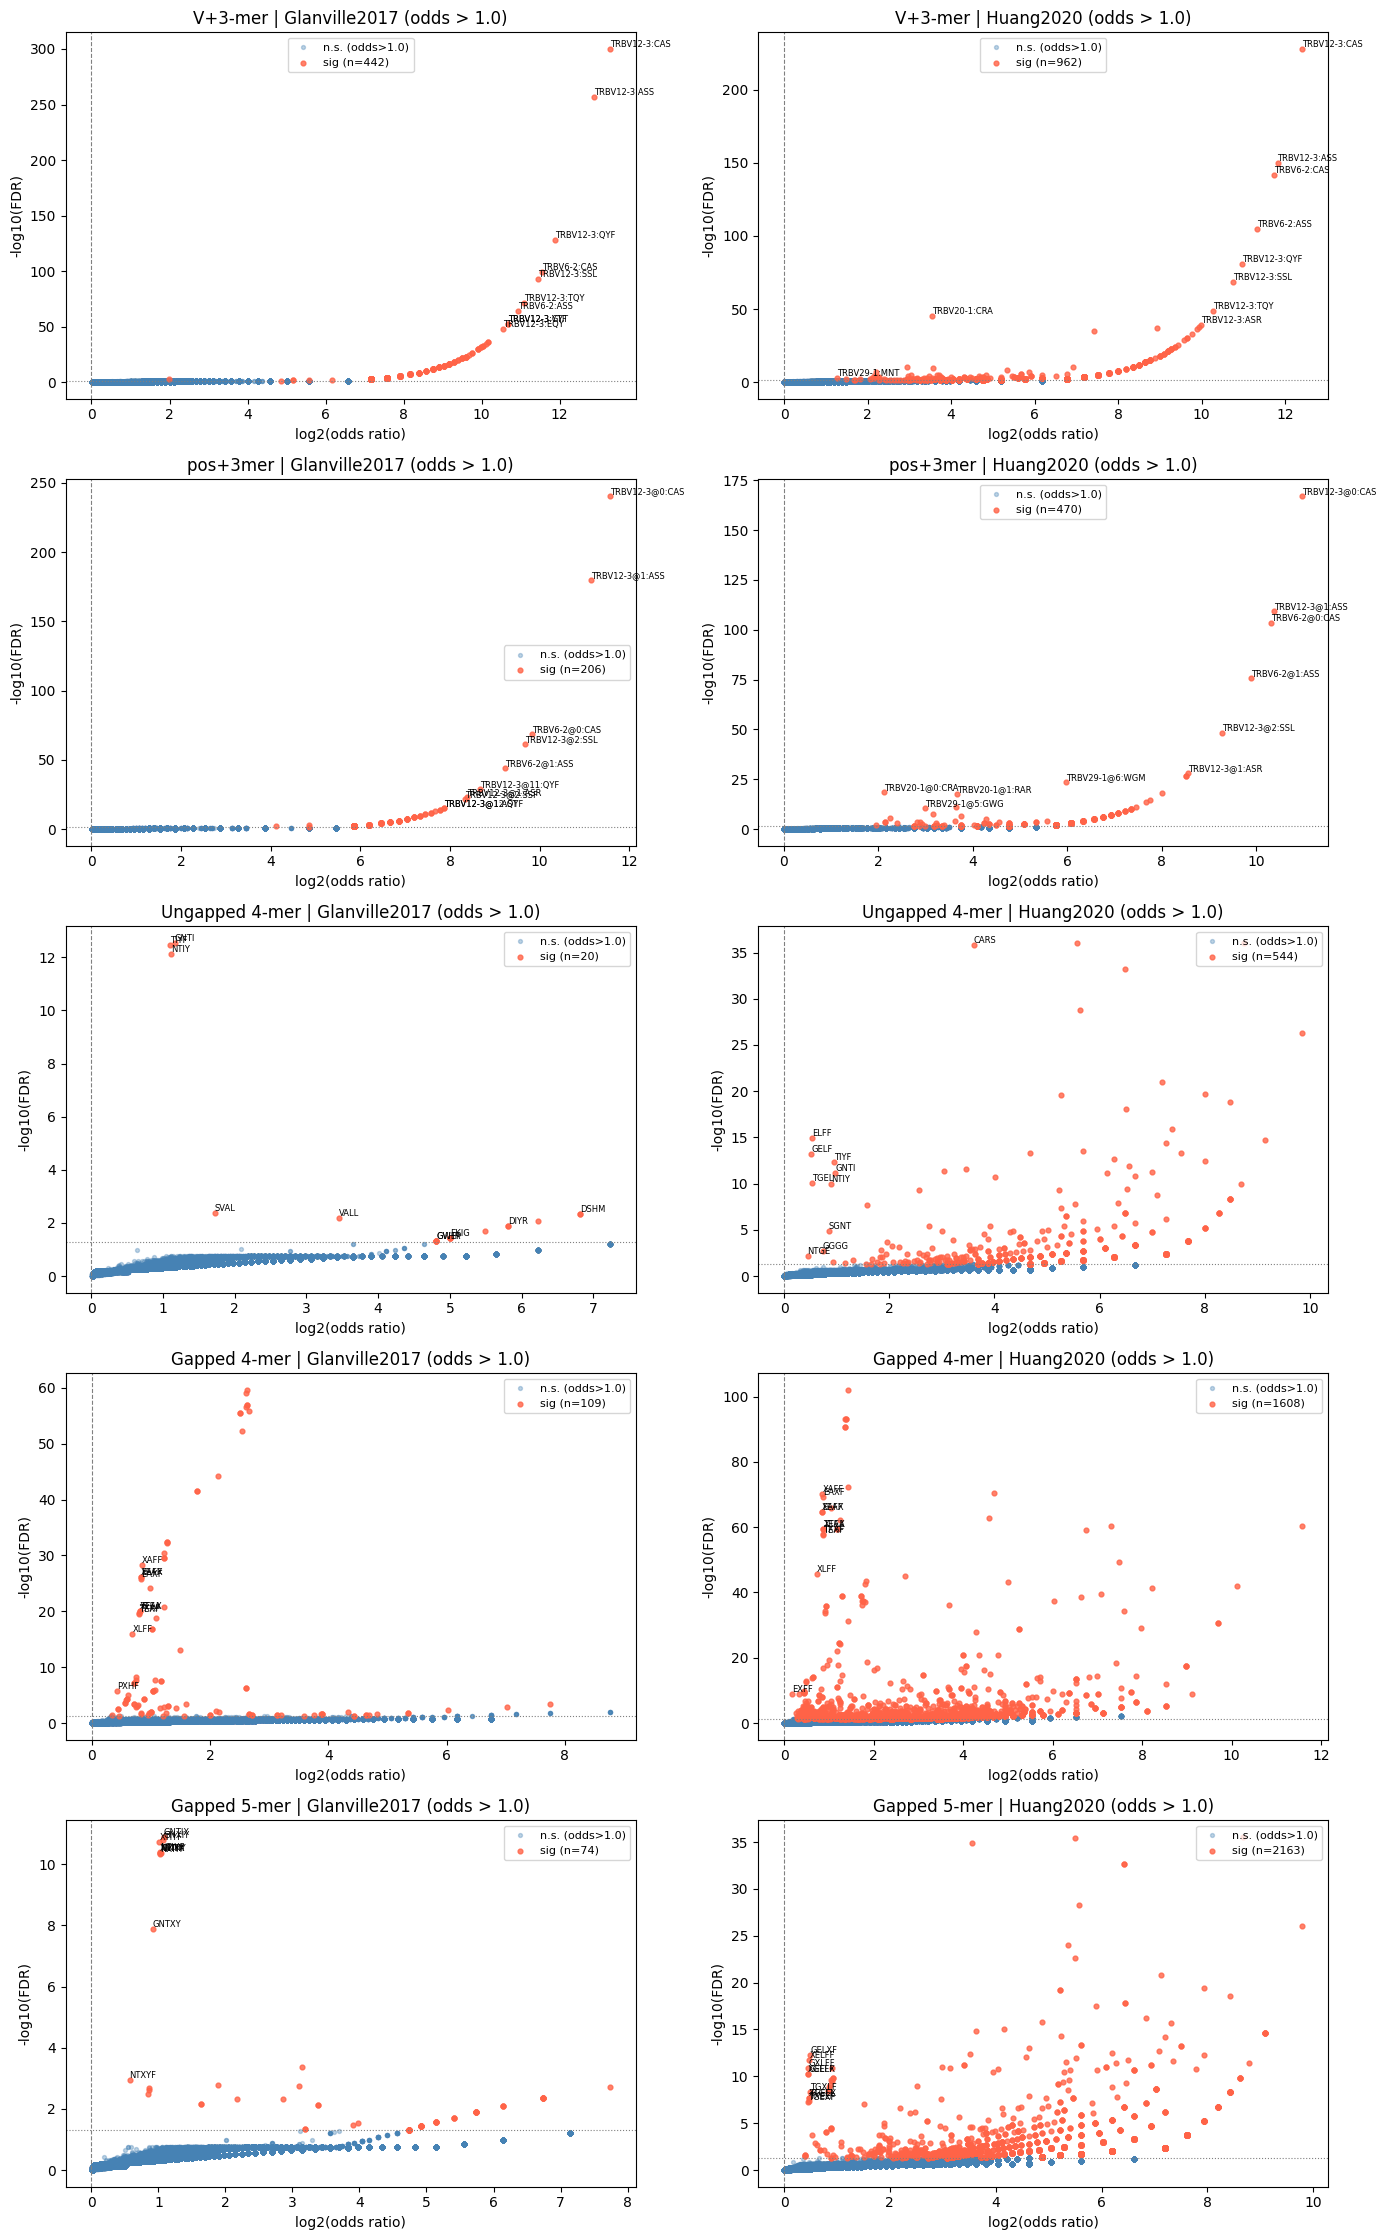

In [ ]:
studies = sorted(next(iter(study_results.values())).keys())
n_studies = len(studies)

fig, axes = plt.subplots(
    nrows=len(FAMILIES),
    ncols=n_studies,
    figsize=(7 * n_studies, 4.5 * len(FAMILIES)),
    squeeze=False,
)

for row_i, family in enumerate(FAMILIES):
    for col_i, study in enumerate(studies):
        ax = axes[row_i, col_i]
        comp = study_results[family][study]['comparison'].copy()
        sig = study_results[family][study]['sig_mask']

        comp = comp[comp['freq_fc'] > 1.0].copy()
        sig = sig.reindex(comp.index).fillna(False)
        if comp.empty:
            ax.set_title(f"{FAMILY_LABELS[family]} | {study} (enrichment>1.0: none)")
            ax.axis('off')
            continue

        comp['log2fc'] = np.log2(comp['freq_fc'].clip(lower=1e-6))
        comp['neglog10p'] = -np.log10(comp['p_val_adj'].clip(lower=1e-300))

        ax.scatter(
            comp.loc[~sig, 'log2fc'],
            comp.loc[~sig, 'neglog10p'],
            s=8, alpha=0.35, color='steelblue', label='n.s. (enrichment>1.0)'
        )
        ax.scatter(
            comp.loc[sig, 'log2fc'],
            comp.loc[sig, 'neglog10p'],
            s=12, alpha=0.8, color='tomato', label=f'sig (n={int(sig.sum())})'
        )

        top = comp[sig].nlargest(TOP_LABELS, 'sample_clonotypes')
        for _, row in top.iterrows():
            token_label = _token_display_name(row.name)
            ax.annotate(token_label, xy=(row['log2fc'], row['neglog10p']), fontsize=6, ha='left', va='bottom')

        ax.axvline(np.log2(SIG_ODDS), color='grey', linestyle='--', linewidth=0.8)
        ax.axhline(-np.log10(SIG_FDR), color='grey', linestyle=':', linewidth=0.8)
        ax.set_xlabel('log2(enrichment ratio)')
        ax.set_ylabel('-log10(FDR)')
        ax.set_title(f'{FAMILY_LABELS[family]} | {study} (enrichment > 1.0)')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Full GLIPH Graph and One-Mode Projections

For each study, all enriched k-mers from all five families are merged and used in a full graph workflow:

- Start with token-clonotype edges from enriched k-mers.
- Add clonotype-clonotype edges from Hamming `<= 1` using the mirpy edit-distance graph builder.
- Expand by one Hamming hop: add all Hamming neighbors of already selected clonotypes.
- Build one-mode projections (graph-theory term):
  - clonotype projection (clonotypes connected if they co-occur with shared enriched tokens and/or Hamming edge)
  - k-mer projection (k-mers connected if at least one clonotype carries both)

In [18]:
def _stimulus_color_map(values: pd.Series) -> dict[str, str]:
    unique_values = [v for v in sorted(values.fillna('').astype(str).str.strip().unique()) if v]
    fallback = ['#bc6c25', '#219ebc', '#b5179e', '#588157', '#ff7f11', '#4d908e']
    colors = {}
    for idx, value in enumerate(unique_values):
        colors[value] = STIMULUS_PALETTE.get(value, fallback[idx % len(fallback)])
    return colors


def _build_augmented_bipartite_graph(
    study_df: pd.DataFrame,
    token_to_clones: dict[str, set[str]],
    clone_to_tokens: dict[str, set[str]],
    token_family: dict[str, str],
    full_clone_graph: ig.Graph,
) -> ig.Graph:
    token_nodes = sorted(token_to_clones)
    clone_nodes = sorted(str(name) for name in full_clone_graph.vs['name'])
    all_nodes = token_nodes + clone_nodes
    node_idx = {name: i for i, name in enumerate(all_nodes)}

    graph = ig.Graph(n=len(all_nodes), directed=False)
    graph.vs['name'] = all_nodes
    graph.vs['kind'] = ['token'] * len(token_nodes) + ['clone'] * len(clone_nodes)

    edges: list[tuple[int, int]] = []
    edge_kind: list[str] = []
    edge_color: list[str] = []
    edge_width: list[float] = []

    for clone_id, tokens in clone_to_tokens.items():
        if clone_id not in node_idx:
            continue
        for token in sorted(tokens):
            if token not in node_idx:
                continue
            edges.append((node_idx[token], node_idx[clone_id]))
            edge_kind.append('token')
            edge_color.append('#c7c7c7')
            edge_width.append(0.5)

    for edge in full_clone_graph.es:
        left = str(full_clone_graph.vs[edge.source]['name'])
        right = str(full_clone_graph.vs[edge.target]['name'])
        if left not in node_idx or right not in node_idx:
            continue
        edges.append((node_idx[left], node_idx[right]))
        is_hamming = bool(edge['is_hamming']) if 'is_hamming' in full_clone_graph.es.attributes() else False
        shared = int(edge['shared_kmers']) if 'shared_kmers' in full_clone_graph.es.attributes() else 0
        edge_kind.append('clone_clone')
        edge_color.append('#4d4d4d' if is_hamming else '#8d99ae')
        edge_width.append(0.8 + 0.2 * np.log2(shared + 1.0))

    if edges:
        graph.add_edges(edges)
        graph.es['kind'] = edge_kind
        graph.es['color'] = edge_color
        graph.es['width'] = edge_width

    dup_map = study_df.set_index('row_id')['duplicate_count'].astype(float).to_dict()
    graph.vs['color'] = [
        FAMILY_COLORS.get(token_family.get(v['name'], ''), '#999999') if v['kind'] == 'token' else '#9e9e9e'
        for v in graph.vs
    ]

    degree_map = {v['name']: graph.degree(v.index) for v in graph.vs}
    graph.vs['size'] = [
        5.0 + 1.8 * np.log2(degree_map.get(v['name'], 0) + 1.0) if v['kind'] == 'token'
        else 2.0 + 2.2 * np.log2(dup_map.get(v['name'], 1.0) + 1.0)
        for v in graph.vs
    ]
    return graph


def _prepare_clone_graph_style(study_df: pd.DataFrame, clone_graph: ig.Graph) -> ig.Graph:
    graph = clone_graph.copy()
    if graph.vcount() == 0:
        return graph
    dup_map = study_df.set_index('row_id')['duplicate_count'].astype(float).to_dict()
    stimulus_map = study_df.set_index('row_id')['stimulus'].astype(str).to_dict()
    stim_colors = _stimulus_color_map(study_df['stimulus'])
    graph.vs['color'] = [stim_colors.get(stimulus_map.get(str(name), ''), '#bdbdbd') for name in graph.vs['name']]
    graph.vs['size'] = [2.0 + 2.2 * np.log2(dup_map.get(str(name), 1.0) + 1.0) for name in graph.vs['name']]
    if graph.ecount() and 'weight' in graph.es.attributes():
        graph.es['width'] = [0.35 + 0.18 * np.log2(float(weight) + 1.0) for weight in graph.es['weight']]
    else:
        graph.es['width'] = [0.5] * graph.ecount()
    graph.es['color'] = [
        '#4d4d4d' if ('is_hamming' in graph.es.attributes() and bool(edge['is_hamming'])) else '#a8dadc'
        for edge in graph.es
    ]
    return graph


def _project_kmer_graph_with_style(
    study_df: pd.DataFrame,
    token_to_clones: dict[str, set[str]],
    token_family: dict[str, str],
) -> ig.Graph:
    graph, token_degree = build_kmer_projection_graph(token_to_clones)
    if graph.vcount() == 0:
        return graph

    stimulus_map = study_df.set_index('row_id')['stimulus'].astype(str).to_dict()
    stim_colors = _stimulus_color_map(study_df['stimulus'])
    token_stimulus = {}
    for token, clone_ids in token_to_clones.items():
        counts = Counter(stimulus_map.get(clone_id, '') for clone_id in clone_ids)
        token_stimulus[token] = counts.most_common(1)[0][0] if counts else ''

    graph.vs['color'] = [
        stim_colors.get(token_stimulus.get(name, ''), FAMILY_COLORS.get(token_family.get(name, ''), '#999999'))
        for name in graph.vs['name']
    ]
    graph.vs['size'] = [4.0 + 1.6 * np.log2(token_degree.get(name, 0) + 1.0) for name in graph.vs['name']]
    if graph.ecount() and 'weight' in graph.es.attributes():
        graph.es['width'] = [0.35 + 0.15 * np.log2(float(weight) + 1.0) for weight in graph.es['weight']]
    else:
        graph.es['width'] = [0.45] * graph.ecount()
    graph.es['color'] = ['#d0d0d0'] * graph.ecount()
    return graph


def _plot_graph(
    graph: ig.Graph,
    title: str,
    *,
    legend_items: list[tuple[str, str]] | None = None,
    label_nodes: list[str] | None = None,
    max_nodes: int = MAX_GRAPH_NODES,
) -> None:
    if graph.vcount() == 0:
        print(f'{title}: no nodes to plot')
        return
    if graph.vcount() > max_nodes:
        print(f'{title}: {graph.vcount()} nodes - subsampling to {max_nodes}')
        keep = sorted(range(graph.vcount()), key=lambda idx: -graph.degree(idx))[:max_nodes]
        graph = graph.induced_subgraph(keep)

    labels = []
    label_nodes = set(label_nodes or [])
    for vertex in graph.vs:
        labels.append(vertex['name'] if vertex['name'] in label_nodes else None)

    layout = graph.layout('fr')
    fig, ax = plt.subplots(figsize=(10, 8))
    ig.plot(
        graph,
        layout=layout,
        target=ax,
        vertex_size=graph.vs['size'] if 'size' in graph.vs.attributes() else 6,
        vertex_color=graph.vs['color'] if 'color' in graph.vs.attributes() else '#9e9e9e',
        vertex_label=labels,
        vertex_label_size=8,
        edge_width=graph.es['width'] if 'width' in graph.es.attributes() else 0.5,
        edge_color=graph.es['color'] if 'color' in graph.es.attributes() else '#cccccc',
    )
    ax.set_title(title)
    if legend_items:
        patches = [mpatches.Patch(color=color, label=label) for label, color in legend_items]
        ax.legend(handles=patches, loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()


def _top_token_labels(token_to_clones: dict[str, set[str]], top_n: int = TOP_LABELS) -> list[str]:
    ranked = sorted(token_to_clones, key=lambda token: (-len(token_to_clones[token]), token))[:top_n]
    return ranked


def _top_clone_labels(study_df: pd.DataFrame, clone_ids: list[str], top_n: int = TOP_LABELS) -> list[str]:
    dup_map = study_df.set_index('row_id')['duplicate_count'].astype(float).to_dict()
    return sorted(clone_ids, key=lambda clone_id: (-dup_map.get(clone_id, 0.0), clone_id))[:top_n]



=== Glanville2017 | full GLIPH graphs ===
Enriched token counts by family: {'v3': 442, 'pos3': 206, 'u4': 20, 'g4': 109, 'g5': 74}
Combined enriched token total: 851
Initial token-linked clonotypes: 2018
Full hamming graph: 3928 nodes / 182 edges
Expanded full clone graph: 2042 nodes / 1633 edges
Glanville2017 | enriched tokens + clonotypes + hamming<=1 edges: 2893 nodes - subsampling to 450


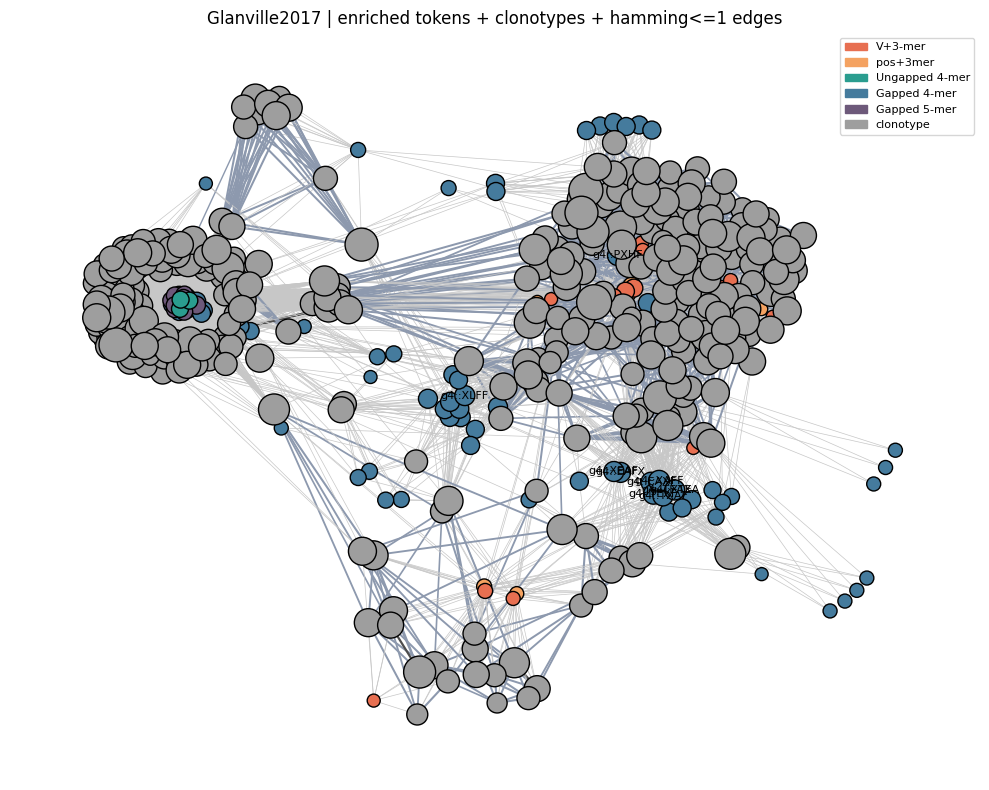

Glanville2017 | full clonotype graph (shared enriched k-mers + hamming<=1): 2042 nodes - subsampling to 450


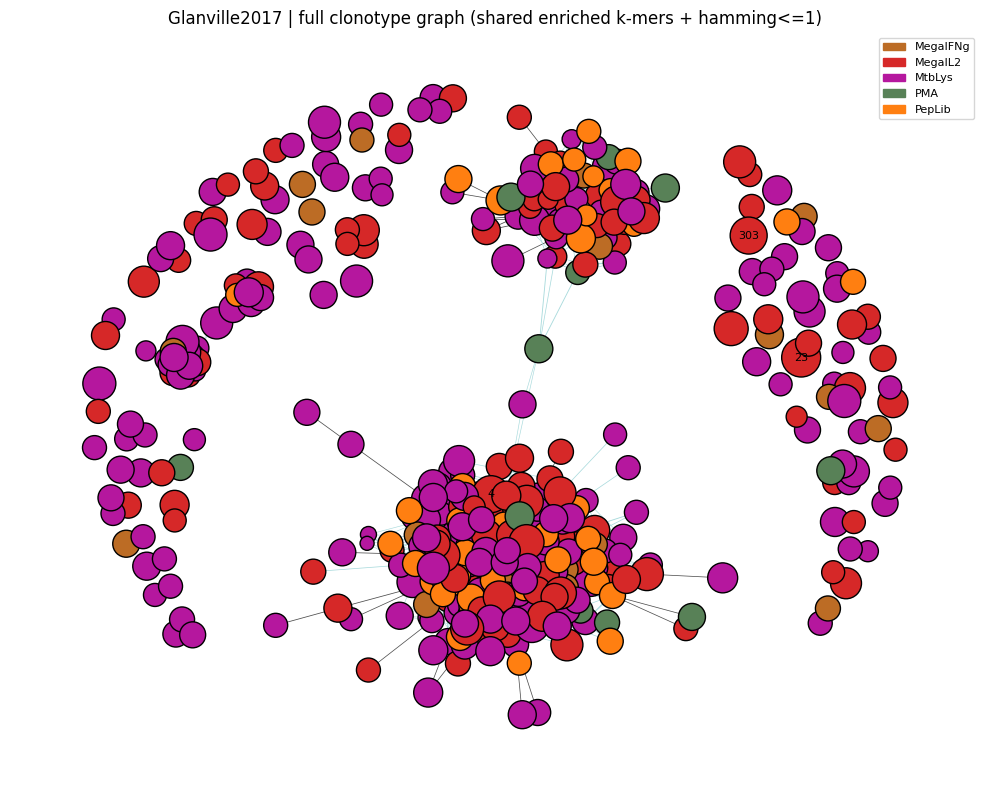

Glanville2017 | k-mer one-mode projection (co-occurrence graph): 851 nodes - subsampling to 450


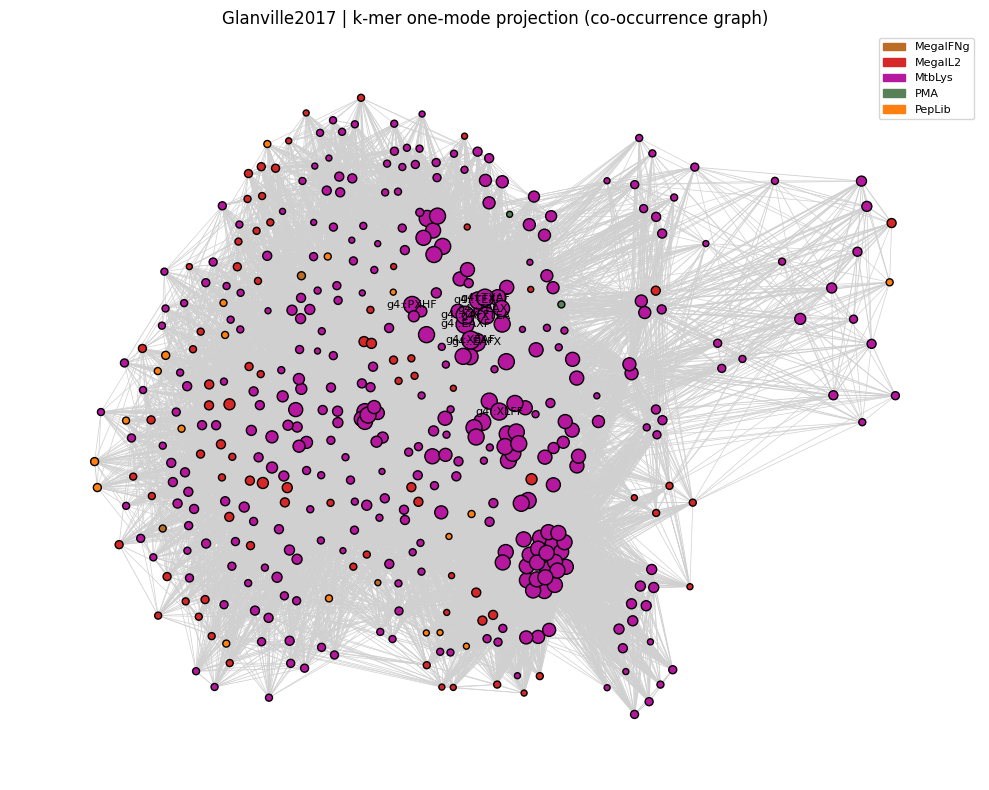


=== Huang2020 | full GLIPH graphs ===
Enriched token counts by family: {'v3': 962, 'pos3': 470, 'u4': 544, 'g4': 1608, 'g5': 2163}
Combined enriched token total: 5747
Initial token-linked clonotypes: 8579
Full hamming graph: 9934 nodes / 1725 edges
Expanded full clone graph: 8721 nodes / 9338 edges
Huang2020 | enriched tokens + clonotypes + hamming<=1 edges: 14468 nodes - subsampling to 450


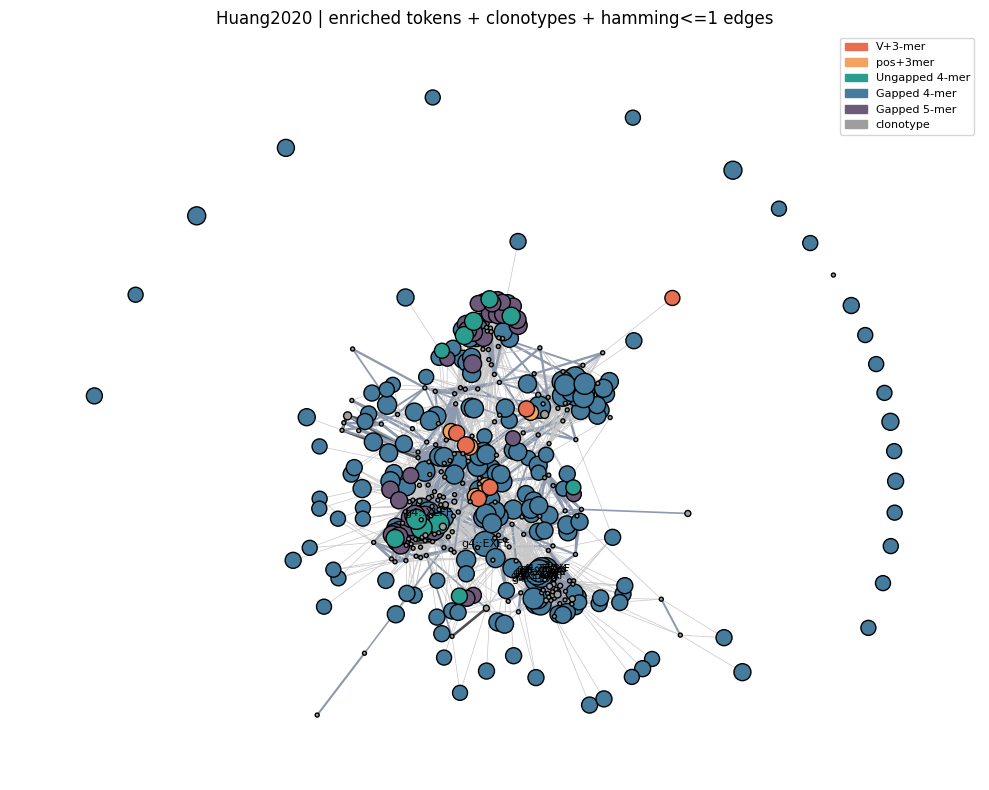

Huang2020 | full clonotype graph (shared enriched k-mers + hamming<=1): 8721 nodes - subsampling to 450


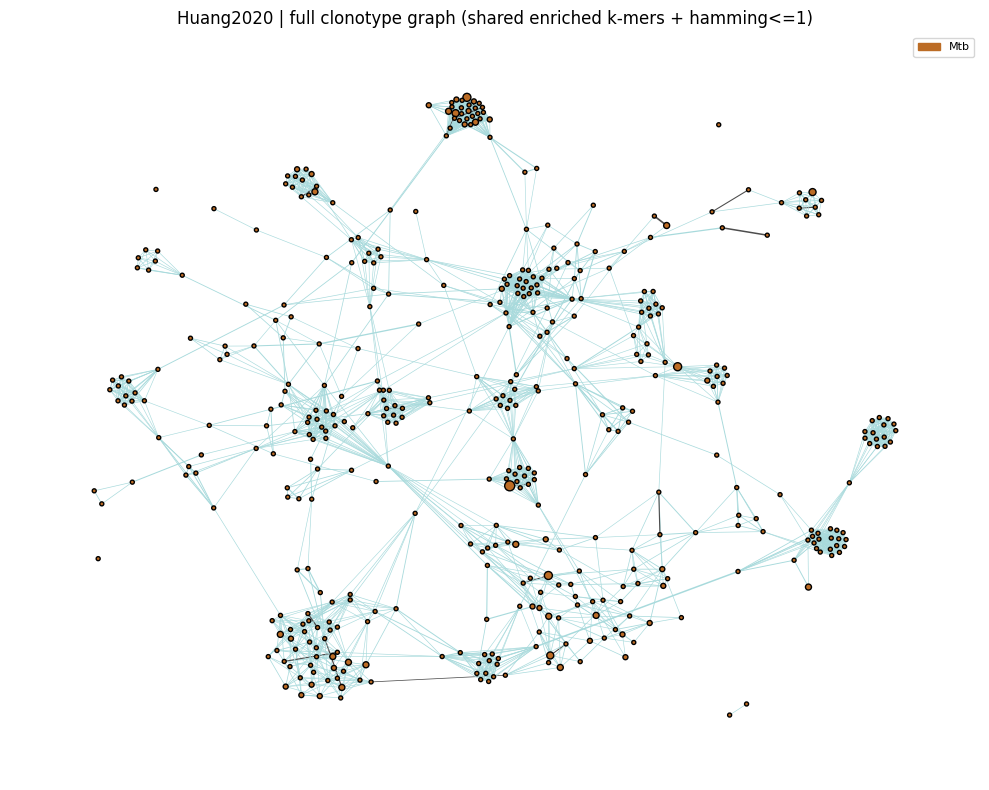

Huang2020 | k-mer one-mode projection (co-occurrence graph): 5747 nodes - subsampling to 450


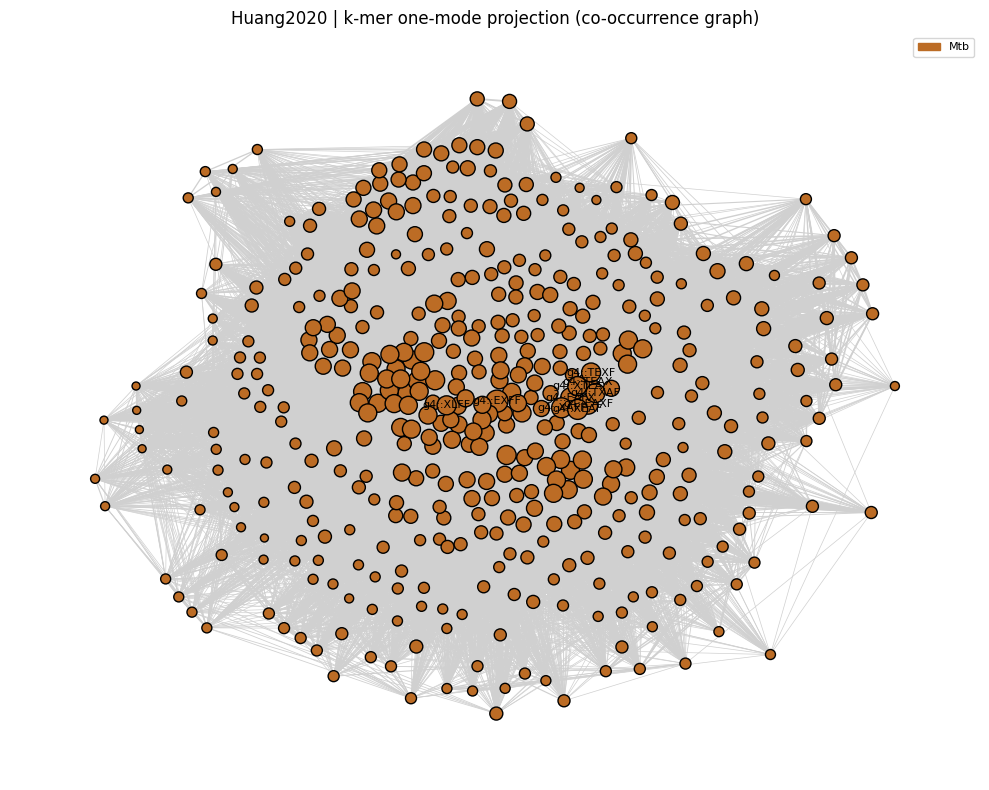

In [19]:
combined_graph_payloads: dict[str, dict[str, object]] = {}

for study in sorted(next(iter(study_results.values())).keys()):
    study_payloads = {family: study_results[family][study] for family in FAMILIES}
    study_df = study_payloads[FAMILIES[0]]['study_df']

    artifacts_by_family = {family: study_payloads[family]['study_art'] for family in FAMILIES}
    enriched_by_family = {family: study_payloads[family]['enriched_tokens'] for family in FAMILIES}
    token_to_clones, clone_to_tokens, token_family = combine_enriched_token_maps(
        artifacts_by_family,
        enriched_by_family,
    )

    full_clone_graph, clone_to_tokens_expanded, hamming_graph = build_full_gliph_clonotype_graph(
        study_df,
        token_to_clones,
        hamming_threshold=1,
        hamming_threads=TOKEN_THREADS,
        expand_hamming_neighbors=True,
        min_kmer_edge_weight=CLONE_EDGE_MIN_WEIGHT,
    )

    combined_graph_payloads[study] = {
        'study_df': study_df,
        'token_to_clones': token_to_clones,
        'clone_to_tokens': clone_to_tokens_expanded,
        'token_family': token_family,
        'full_clone_graph': full_clone_graph,
        'hamming_graph': hamming_graph,
    }

    print(f'\n=== {study} | full GLIPH graphs ===')
    family_counts = {family: len(study_payloads[family]['enriched_tokens']) for family in FAMILIES}
    print('Enriched token counts by family:', family_counts)
    print('Combined enriched token total:', len(token_to_clones))
    print('Initial token-linked clonotypes:', len(clone_to_tokens))
    print('Full hamming graph:', hamming_graph.vcount(), 'nodes /', hamming_graph.ecount(), 'edges')
    print('Expanded full clone graph:', full_clone_graph.vcount(), 'nodes /', full_clone_graph.ecount(), 'edges')

    bipartite_graph = _build_augmented_bipartite_graph(
        study_df,
        token_to_clones,
        clone_to_tokens_expanded,
        token_family,
        full_clone_graph,
    )
    _plot_graph(
        bipartite_graph,
        title=f'{study} | enriched tokens + clonotypes + hamming<=1 edges',
        legend_items=[(FAMILY_LABELS[family], FAMILY_COLORS[family]) for family in FAMILIES] + [('clonotype', '#9e9e9e')],
        label_nodes=_top_token_labels(token_to_clones),
    )

    clone_graph = _prepare_clone_graph_style(study_df, full_clone_graph)
    stim_legend = [(label, color) for label, color in _stimulus_color_map(study_df['stimulus']).items()]
    _plot_graph(
        clone_graph,
        title=f'{study} | full clonotype graph (shared enriched k-mers + hamming<=1)',
        legend_items=stim_legend,
        label_nodes=_top_clone_labels(study_df, [str(name) for name in clone_graph.vs['name']]),
    )

    kmer_graph = _project_kmer_graph_with_style(study_df, token_to_clones, token_family)
    _plot_graph(
        kmer_graph,
        title=f'{study} | k-mer one-mode projection (co-occurrence graph)',
        legend_items=stim_legend,
        label_nodes=_top_token_labels(token_to_clones),
    )


In [11]:
def _canonical_study_name(study_name: str) -> str | None:
    s = str(study_name).lower()
    for canon, keyword in STUDY_KEYWORDS.items():
        if keyword in s:
            return canon
    return None


def _purity_score(y_true: pd.Series, y_pred: pd.Series) -> float:
    tab = pd.crosstab(y_pred, y_true)
    if tab.empty:
        return float('nan')
    return float(tab.max(axis=1).sum() / tab.to_numpy().sum())


def _cluster_projected_graph(
    study_df: pd.DataFrame,
    clone_graph: ig.Graph,
    method: str,
    min_cluster_size: int = MIN_CLUSTER_SIZE,
) -> tuple[dict[str, int], dict[str, int]]:
    clone_ids_all = study_df['row_id'].astype(str).tolist()
    labels_all = {clone_id: -1 for clone_id in clone_ids_all}
    if clone_graph.vcount() == 0 or clone_graph.ecount() == 0:
        return labels_all, {'n_clusters': 0, 'n_clustered': 0, 'n_total': len(clone_ids_all)}

    if method == 'components':
        membership = np.full(clone_graph.vcount(), -1, dtype=int)
        for comp_id, vertices in enumerate(clone_graph.components()):
            for vertex in vertices:
                membership[vertex] = comp_id
    elif method == 'leiden':
        membership = np.array(
            clone_graph.community_leiden(weights='weight', objective_function='modularity', n_iterations=5).membership,
            dtype=int,
        )
    else:
        raise ValueError(f'Unknown method: {method}')

    keep_mask = np.zeros_like(membership, dtype=bool)
    for label in np.unique(membership):
        if (membership == label).sum() >= min_cluster_size:
            keep_mask |= (membership == label)
    membership = np.where(keep_mask, membership, -1)

    for clone_id, label in zip(clone_graph.vs['name'], membership):
        labels_all[str(clone_id)] = int(label)

    stats = {
        'n_clusters': int(len(set(membership[membership >= 0]))),
        'n_clustered': int((membership >= 0).sum()),
        'n_total': len(clone_ids_all),
    }
    return labels_all, stats


def _make_cluster_table(
    study_df: pd.DataFrame,
    clone_to_tokens: dict[str, set[str]],
    token_family: dict[str, str],
    labels_map: dict[str, int],
    top_n: int = 15,
) -> pd.DataFrame:
    rows = []
    study_index = study_df.set_index('row_id')
    valid_labels = sorted({label for label in labels_map.values() if label >= 0})
    for label in valid_labels:
        member_ids = [clone_id for clone_id, value in labels_map.items() if value == label]
        member_rows = study_index.loc[study_index.index.intersection(member_ids)]
        token_support = Counter()
        family_support = Counter()
        for clone_id in member_ids:
            for token in clone_to_tokens.get(clone_id, set()):
                token_support[token] += 1
                family_support[token_family.get(token, _family_from_token(token))] += 1
        top_tokens = ', '.join(
            f"{_token_display_name(token)} ({count})"
            for token, count in token_support.most_common(5)
        )
        top_families = ', '.join(f'{FAMILY_LABELS[family]}:{count}' for family, count in family_support.most_common())
        rows.append({
            'cluster': label,
            'size': len(member_ids),
            'mean_duplicate_count': float(member_rows['duplicate_count'].mean()) if len(member_rows) else np.nan,
            'top_families': top_families,
            'top_enriched_tokens': top_tokens,
            'stimuli': ', '.join(member_rows['stimulus'].astype(str).value_counts().head(3).index.tolist()),
            'sequences': ' | '.join(member_rows['junction_aa'].astype(str).tolist()[:5]),
        })
    if not rows:
        return pd.DataFrame(columns=['cluster', 'size', 'mean_duplicate_count', 'top_families', 'top_enriched_tokens', 'stimuli', 'sequences'])
    return pd.DataFrame(rows).sort_values('size', ascending=False).head(top_n)


def _concordance_row(
    study_df: pd.DataFrame,
    labels_map: dict[str, int],
    target_col: str,
    target_name: str,
    canonical_study: str | None,
    method: str,
) -> dict[str, object]:
    tmp = study_df[['row_id', target_col]].copy()
    tmp['target'] = tmp[target_col].fillna('').astype(str).str.strip()
    tmp = tmp[~tmp['target'].str.lower().isin({'', 'nan', 'none', 'na'})].copy()
    n_target_total = len(tmp)
    if n_target_total == 0:
        return {
            'canonical_study': canonical_study,
            'reference_id': str(study_df['reference_id'].iloc[0]),
            'method': method,
            'config': f'combined+{method}',
            'target_name': target_name,
            'n_total': len(study_df),
            'n_target_total': 0,
            'n_eval': 0,
            'coverage': 0.0,
            'ami': np.nan,
            'nmi': np.nan,
            'ari': np.nan,
            'purity': np.nan,
        }

    tmp['pred_cluster'] = tmp['row_id'].map(labels_map).fillna(-1).astype(int)
    coverage = float((tmp['pred_cluster'] >= 0).mean())
    eval_df = tmp[tmp['pred_cluster'] >= 0].copy()

    if len(eval_df) < 2 or eval_df['pred_cluster'].nunique() < 2 or eval_df['target'].nunique() < 2:
        ami = nmi = ari = purity = np.nan
    else:
        ami = adjusted_mutual_info_score(eval_df['target'], eval_df['pred_cluster'])
        nmi = normalized_mutual_info_score(eval_df['target'], eval_df['pred_cluster'])
        ari = adjusted_rand_score(eval_df['target'], eval_df['pred_cluster'])
        purity = _purity_score(eval_df['target'], eval_df['pred_cluster'])

    return {
        'canonical_study': canonical_study,
        'reference_id': str(study_df['reference_id'].iloc[0]),
        'method': method,
        'config': f'combined+{method}',
        'target_name': target_name,
        'n_total': len(study_df),
        'n_target_total': n_target_total,
        'n_eval': len(eval_df),
        'coverage': coverage,
        'ami': ami,
        'nmi': nmi,
        'ari': ari,
        'purity': purity,
    }


In [20]:
cluster_tables: dict[tuple[str, str], pd.DataFrame] = {}
cluster_labels: dict[tuple[str, str], dict[str, int]] = {}
cluster_stats_rows: list[dict[str, object]] = []
concordance_rows: list[dict[str, object]] = []

for study, payload in combined_graph_payloads.items():
    study_df = payload['study_df']
    clone_to_tokens = payload['clone_to_tokens']
    token_family = payload['token_family']
    full_clone_graph = payload['full_clone_graph']
    canonical = _canonical_study_name(study)
    total_enriched = len(payload['token_to_clones'])
    n_hamming_edges = int(sum(bool(v) for v in full_clone_graph.es['is_hamming'])) if (full_clone_graph.ecount() and 'is_hamming' in full_clone_graph.es.attributes()) else 0

    for method in CLUSTER_METHODS:
        labels_map, stats = _cluster_projected_graph(
            study_df,
            full_clone_graph,
            method=method,
            min_cluster_size=MIN_CLUSTER_SIZE,
        )
        cluster_labels[(study, method)] = labels_map
        cluster_tables[(study, method)] = _make_cluster_table(study_df, clone_to_tokens, token_family, labels_map)

        cluster_stats_rows.append({
            'canonical_study': canonical,
            'reference_id': study,
            'method': method,
            'config': f'full_gliph+{method}',
            'n_enriched_tokens_total': total_enriched,
            'n_full_graph_nodes': int(full_clone_graph.vcount()),
            'n_full_graph_edges': int(full_clone_graph.ecount()),
            'n_hamming_edges': n_hamming_edges,
            'n_clusters': stats['n_clusters'],
            'n_clustered': stats['n_clustered'],
            'n_total': stats['n_total'],
            'clustered_frac': stats['n_clustered'] / stats['n_total'] if stats['n_total'] else np.nan,
        })

        concordance_rows.append(_concordance_row(
            study_df=study_df,
            labels_map=labels_map,
            target_col='gliph_cluster_id',
            target_name='gliph_cluster_id',
            canonical_study=canonical,
            method=method,
        ))
        if canonical == 'Glanville2017':
            concordance_rows.append(_concordance_row(
                study_df=study_df,
                labels_map=labels_map,
                target_col='stimulus',
                target_name='stimulus',
                canonical_study=canonical,
                method=method,
            ))
        elif canonical == 'Huang2020':
            concordance_rows.append(_concordance_row(
                study_df=study_df,
                labels_map=labels_map,
                target_col='epitope',
                target_name='epitope',
                canonical_study=canonical,
                method=method,
            ))

cluster_stats_df = pd.DataFrame(cluster_stats_rows).sort_values(
    ['canonical_study', 'reference_id', 'method']
).reset_index(drop=True)
concordance_df = pd.DataFrame(concordance_rows).sort_values(
    ['canonical_study', 'reference_id', 'target_name', 'method']
).reset_index(drop=True)

print('Cluster statistics table:')
display(cluster_stats_df)

print('Concordance table:')
display(concordance_df)


Cluster statistics table:


,canonical_study,reference_id,method,config,n_enriched_tokens_total,n_full_graph_nodes,n_full_graph_edges,n_hamming_edges,n_clusters,n_clustered,n_total,clustered_frac
0,Glanville2017,Glanville2017,components,full_gliph+components,851,2042,1633,108,23,403,3928,0.102597
1,Glanville2017,Glanville2017,leiden,full_gliph+leiden,851,2042,1633,108,32,403,3928,0.102597
2,Huang2020,Huang2020,components,full_gliph+components,5747,8721,9338,1607,160,3170,9934,0.319106
3,Huang2020,Huang2020,leiden,full_gliph+leiden,5747,8721,9338,1607,210,3168,9934,0.318905


Concordance table:


,canonical_study,reference_id,method,config,target_name,n_total,n_target_total,n_eval,coverage,ami,nmi,ari,purity
0,Glanville2017,Glanville2017,components,combined+components,gliph_cluster_id,3928,1287,192,0.149184,0.221187,0.548165,0.035010,0.364583
1,Glanville2017,Glanville2017,leiden,combined+leiden,gliph_cluster_id,3928,1287,192,0.149184,0.459400,0.790396,0.275818,0.468750
2,Glanville2017,Glanville2017,components,combined+components,stimulus,3928,3928,403,0.102597,0.003256,0.081921,-0.039490,0.535980
3,Glanville2017,Glanville2017,leiden,combined+leiden,stimulus,3928,3928,403,0.102597,-0.001091,0.071420,-0.011421,0.538462
4,Huang2020,Huang2020,components,combined+components,epitope,9934,0,0,0.000000,NaN,NaN,NaN,NaN
5,Huang2020,Huang2020,leiden,combined+leiden,epitope,9934,0,0,0.000000,NaN,NaN,NaN,NaN
6,Huang2020,Huang2020,components,combined+components,gliph_cluster_id,9934,4493,2116,0.470955,0.085459,0.374786,0.000929,0.165879
7,Huang2020,Huang2020,leiden,combined+leiden,gliph_cluster_id,9934,4493,2114,0.470510,0.333583,0.769468,0.071517,0.258751



=== full GLIPH graph + components | Glanville2017 ===


,cluster,size,mean_duplicate_count,top_families,top_enriched_tokens,stimuli,sequences
0,5,303,4981.287129,"V+3-mer:2546, pos+3mer:1489, Gapped 4-mer:912,...","TRBV12-3@0:CAS (206), TRBV12-3:CAS (206), TRBV...","MtbLys, MegaIL2, PepLib",CASSKLEGLEQFF | CASRRQGGAYEQYF | CASSLDVDYGYTF...
8,118,26,4518.846154,"Gapped 5-mer:200, Gapped 4-mer:194, Ungapped 4...","SXAL (18), XVAL (17), VALX (17), SVALX (17), X...","MtbLys, MegaIL2, MegaIFNg",CSASVRLFGTDTQYF | CASSVALMGGELFF | CSVALSGQGKY...
12,234,5,2903.000000,Gapped 4-mer:50,"GEXF (5), XGEL (4), ELFX (4), ELXF (4), XLFF (4)","MtbLys, MegaIL2, PMA",CASSQQGTGELFF | CASSQQGTGEAFF | CASSQQGPGELFF ...
9,137,5,4414.200000,"Gapped 4-mer:49, Gapped 5-mer:4","DQNX (5), XDQN (5), DQNXE (4), XTEA (3), TEXF (3)","MtbLys, PMA, MegaIL2",CSGKGTDQNTEAFF | CASSLDQNNEQFF | CASSPDQNTEAFF...
16,346,4,7429.500000,Gapped 4-mer:51,"XRSM (4), RSMX (4), MXTE (2), XTEA (2), TEXF (2)","MtbLys, MegaIL2, MegaIFNg",CASNRQPRSMGTEAFF | CASSYRSMEKLFF | CASSRSMMGTG...
14,281,4,6725.500000,Gapped 4-mer:1,GEXF (1),"MtbLys, MegaIL2",CASSPGRVEQFF | CASSPGRGEQYF | CASSPGRGEQFF | C...
1,52,4,2122.000000,"Gapped 4-mer:14, Gapped 5-mer:2","WXKA (3), RAWXK (2), XAFF (1), GXAF (1), SPLX (1)","MtbLys, PepLib",CASSLRAWGKADYGYTF | CASGWDKASANNEQFF | CASSRLQ...
10,198,4,4025.250000,Gapped 4-mer:36,"SPLX (4), PLXF (4), PLHX (4), SXLH (4), XSPL (4)",MegaIL2,CSARSRTGDSPLHF | CSARERTGDSPLHF | CSARDRTGDSPL...
11,232,4,1677.750000,Gapped 4-mer:2,GXGN (2),MtbLys,CSARSQGNEQFF | CSARGQGNEQYF | CSARGQGNEQFF | C...
6,99,4,4090.000000,"Gapped 4-mer:12, pos+3mer:4","XGEA (4), TRBV20-1@8:EAK (4), GXEA (4), GEAX (4)","MegaIL2, MtbLys",CSARSSGGEAKNIQYF | CSARASGGEAKNIQYF | CSARAGGG...



=== full GLIPH graph + leiden | Glanville2017 ===


,cluster,size,mean_duplicate_count,top_families,top_enriched_tokens,stimuli,sequences
4,18,69,2797.304348,"V+3-mer:502, pos+3mer:246, Gapped 4-mer:167, G...","TRBV6-2:CAS (60), TRBV6-2@0:CAS (60), TRBV6-2:...","MtbLys, MegaIL2, PepLib",CASRGTGTGNYGYTF | CASRGTGRTGNTIYF | CASSKLGNEQ...
3,17,50,5229.200000,"V+3-mer:472, pos+3mer:291, Gapped 4-mer:175","TRBV12-3@0:CAS (47), TRBV12-3:CAS (47), TRBV12...","MtbLys, MegaIL2, PepLib",CASRRQGGAYEQYF | CASSLGQGRGGYTF | CASSSSGTGEKL...
0,5,48,5344.750000,"V+3-mer:389, Gapped 4-mer:260, pos+3mer:242, G...","TRBV12-3@0:CAS (42), TRBV12-3:CAS (42), TRBV12...","MtbLys, MegaIL2, PepLib",CASSKLEGLEQFF | CASSQLENTEAFF | CASSLIENTEAFF ...
6,39,45,9491.644444,"V+3-mer:355, pos+3mer:228, Gapped 4-mer:18, Ga...","TRBV12-3:CAS (36), TRBV12-3@0:CAS (36), TRBV12...","MtbLys, MegaIL2, PepLib",CASSLQEKQETQYF | CASSLEETQYF | CASSPGLTSWSSTDT...
1,7,35,5327.428571,"V+3-mer:323, pos+3mer:177, Gapped 4-mer:129","TRBV12-3@0:CAS (31), TRBV12-3:CAS (31), TRBV12...","MtbLys, MegaIL2, PMA",CASTNSGSNQPQHF | CASSLGQTSYNSPLHF | CASSSGPLNS...
15,142,24,4507.125000,"V+3-mer:201, pos+3mer:136, Gapped 4-mer:3","TRBV12-3:ASS (21), TRBV12-3@1:ASS (21), TRBV12...","MtbLys, MegaIL2, PepLib",CASSLDVDYGYTF | CASSTLRLRNIQYF | CASSFPRESDTQY...
14,124,17,4419.470588,"Gapped 5-mer:93, Gapped 4-mer:88, Ungapped 4-m...","XVAL (17), VALX (17), SVALX (17), XSVAL (17), ...","MtbLys, MegaIL2, MegaIFNg",CASSVALMGGELFF | CSVALSGQGKYF | CASSVALYANEQFF...
2,10,11,1893.818182,"V+3-mer:127, pos+3mer:51, Gapped 4-mer:4","TRBV12-3@0:CAS (11), TRBV12-3:CAS (11), TRBV12...","MtbLys, MegaIL2, MegaIFNg",CASLRASGANVLTF | CASRYRHRDALGQPQHF | CASSPHRRV...
5,20,11,3130.636364,"Gapped 4-mer:156, Gapped 5-mer:133, V+3-mer:90...","GNXIY (11), XGNTI (11), GNXI (11), TIXF (11), ...","MegaIL2, MtbLys, PepLib",CASSLVTAGNTIYF | CASSLSVSGNTIYF | CASSLSQPAGNT...
17,179,10,2128.400000,"V+3-mer:87, pos+3mer:59, Gapped 5-mer:4, Ungap...","TRBV12-3@12:QFF (9), TRBV12-3@0:CAS (9), TRBV1...","MtbLys, MegaIL2",CASRLGGLAEDEQFF | CASSSRDGRYNEQFF | CASSLGALGI...



=== full GLIPH graph + components | Huang2020 ===


...


=== full GLIPH graph + leiden | Huang2020 ===


,cluster,size,mean_duplicate_count,top_families,top_enriched_tokens,stimuli,sequences
18,70,207,1.309179,"Gapped 4-mer:1422, V+3-mer:1387, pos+3mer:832,...","TRBV12-3@0:CAS (138), TRBV12-3:CAS (138), TRBV...",Mtb,CASSPLVAGSSYEQYF | CASTHGLAVYNEQFF | CASVGHTEA...
29,148,175,1.394286,"Gapped 4-mer:1442, Gapped 5-mer:420, Ungapped ...","EXFF (43), XLFF (16), XAFF (15), EAXF (14), EA...",Mtb,CASSPFWGTGELFF | CASSFGRLAYPEQYF | CASSLVGHEVC...
28,132,124,1.491935,"Gapped 4-mer:1016, V+3-mer:760, pos+3mer:448, ...","TRBV6-2:CAS (81), TRBV6-2@0:CAS (81), EXFF (60...",Mtb,CASRSRGGRTYNEQFF | CASTLTGHTGELFF | CASRPSTDTQ...
11,44,113,1.433628,"Gapped 4-mer:1252, Gapped 5-mer:660, Ungapped ...","EXFF (27), CAXSC (24), AXSC (24), XSSC (23), S...",Mtb,CASCGSSYNSPLHF | CASCLFGGGNSPLHF | CASSCLQGASG...
3,9,91,1.241758,"Gapped 4-mer:801, Gapped 5-mer:375, Ungapped 4...","EXFF (52), KEXFF (24), KEXF (24), XKEQ (24), K...",Mtb,CASSLDPEDANTGELFF | CASSMPGLSGPKEQFF | CASSMPG...
0,1,90,1.677778,"Gapped 4-mer:550, Gapped 5-mer:331, Ungapped 4...","XYGQ (21), YGQX (21), GQXF (20), YGQXF (16), Y...",Mtb,CASSKDSGLPYEQYF | CASSLDAHYTGQFF | CASSPGDEQDF...
55,332,89,1.707865,"Gapped 4-mer:889, Gapped 5-mer:440, Ungapped 4...","GNXI (16), TIXF (16), GXTIY (16), TIYF (16), X...",Mtb,CASSLAEGAKIEQYF | CASSLDPGMNQPQHF | CASSQEMGGT...
10,29,87,1.482759,"Gapped 4-mer:830, Gapped 5-mer:253, Ungapped 4...","PXHF (21), EXFF (20), QPXH (18), PQHX (15), XQ...",Mtb,CASSQVIVPHHSYEQYF | CASSLMRGGGTGELFF | CASSPQG...
2,8,78,1.384615,"Gapped 4-mer:769, Gapped 5-mer:263, Ungapped 4...","XQHF (29), QXQH (27), PQXF (23), XQPQ (23), QP...",Mtb,CASSGIRRRLRLAGGHDEQFF | CASSGIRRRLRLAGGHEEQFF ...
30,154,77,1.571429,"Gapped 4-mer:795, Gapped 5-mer:292, Ungapped 4...","EXFF (31), EAXF (20), XAFF (20), XEAF (20), EA...",Mtb,CASSLALNTEAFF | CASSLAMNTEAFF | CASSLVMNTEAFF ...


,canonical_study,reference_id,method,config,target_name,n_total,n_target_total,n_eval,coverage,ami,nmi,ari,purity
0,Glanville2017,Glanville2017,components,combined+components,gliph_cluster_id,3928,1287,192,0.149184,0.221187,0.548165,0.035010,0.364583
1,Glanville2017,Glanville2017,leiden,combined+leiden,gliph_cluster_id,3928,1287,192,0.149184,0.459400,0.790396,0.275818,0.468750
2,Glanville2017,Glanville2017,components,combined+components,stimulus,3928,3928,403,0.102597,0.003256,0.081921,-0.039490,0.535980
3,Glanville2017,Glanville2017,leiden,combined+leiden,stimulus,3928,3928,403,0.102597,-0.001091,0.071420,-0.011421,0.538462
4,Huang2020,Huang2020,components,combined+components,epitope,9934,0,0,0.000000,NaN,NaN,NaN,NaN
5,Huang2020,Huang2020,leiden,combined+leiden,epitope,9934,0,0,0.000000,NaN,NaN,NaN,NaN
6,Huang2020,Huang2020,components,combined+components,gliph_cluster_id,9934,4493,2116,0.470955,0.085459,0.374786,0.000929,0.165879
7,Huang2020,Huang2020,leiden,combined+leiden,gliph_cluster_id,9934,4493,2114,0.470510,0.333583,0.769468,0.071517,0.258751


Target-label availability:


,study,n_rows,n_with_gliph_cluster_id,n_with_stimulus,n_with_epitope
0,Glanville2017,3928,1287,3928,0
1,Huang2020,9934,4493,9934,0


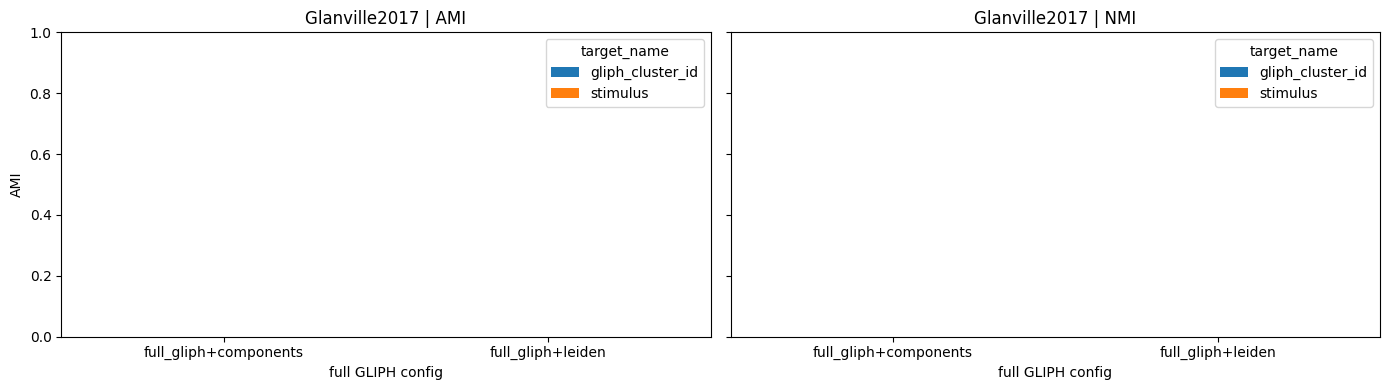

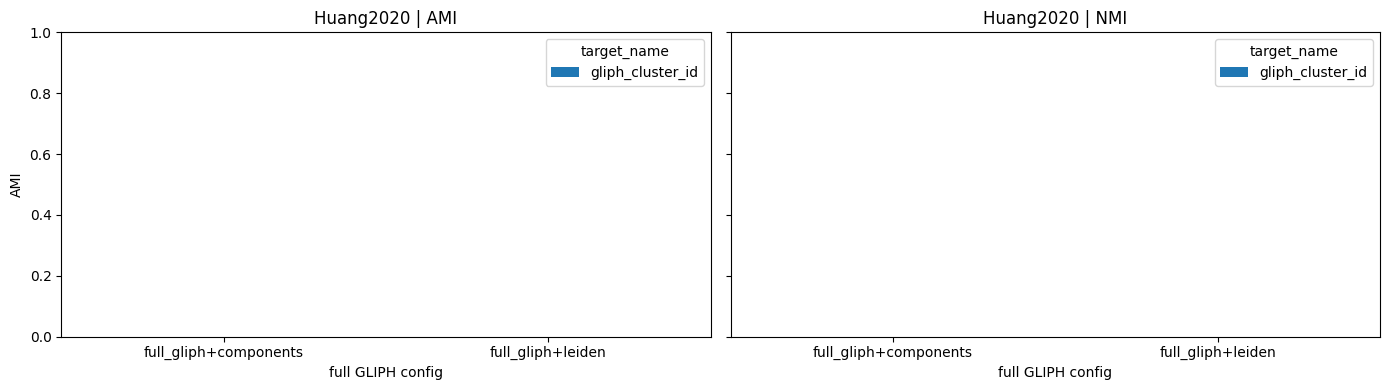

## End-of-Notebook Summary

- GLIPH input was deduplicated to unique `(reference_id, v_gene, junction_aa)` clonotypes before token counting.
- Token extraction uses `clonotype` counts, `4` threads, `CONTROL_SAMPLE=1,000,000`, and V-only control normalization.
- Separate Fisher tests were run for `v3`, `pos3`, `u4`, `g4`, and `g5` with cutoffs `FDR < 0.05`, `odds > 1.0`, and `sample_clonotypes >= 2`.
- Volcano plots show only the `odds > 1.0` side as requested.
- Full GLIPH graph step: merge enriched tokens, add clonotype-clonotype Hamming<=1 edges, then expand by one Hamming hop around graph clonotypes.
- The heterogeneous plot includes token-clonotype edges and additional clone-clone Hamming/shared-token edges.
- One-mode projections are used for downstream analysis:
  - clonotype projection: communities from connected components and Leiden
  - k-mer projection: token co-occurrence graph where tokens share at least one clonotype
- Node styling:
  - enriched k-mers: colored by k-mer family, size by node degree
  - clonotypes: grey in the heterogeneous graph, and colored by stimulus in the clonotype projection, size by `log2(duplicate_count + 1)`
- Cluster token summaries are computed from actual member clonotypes, so top token lists are consistent with shown example sequences.
- Concordance targets:
  - `Glanville2017`: `stimulus` and `gliph_cluster_id`
  - `Huang2020`: `gliph_cluster_id` only in the current dataset snapshot (`epitope` is empty)
- Glanville2017 enriched token counts: v3=442, pos3=206, u4=20, g4=109, g5=74.
- Huang2020 enriched token counts: v3=962, pos3=470, u4=544, g4=1608, g5=2163.
- Glanville2017 vs gliph_cluster_id: best `combined+leiden` with AMI=0.459, NMI=0.790, ARI=0.276, purity=0.469, coverage=14.9%.
- Glanville2017 vs stimulus: best `combined+components` with AMI=0.003, NMI=0.082, ARI=-0.039, purity=0.536, coverage=10.3%.
- Huang2020 vs gliph_cluster_id: best `combined+leiden` with AMI=0.334, NMI=0.769, ARI=0.072, purity=0.259, coverage=47.1%.
- Huang2020 vs epitope: no non-empty labels in this dataset snapshot.

In [ ]:
# Top cluster previews per study and graph community method
for key in sorted(cluster_tables.keys()):
    study, method = key
    tab = cluster_tables[key]
    print(f'\n=== full GLIPH graph + {method} | {study} ===')
    if tab.empty:
        print('  (no clusters)')
    else:
        display(tab.head(10))

focus_studies = {'Glanville2017', 'Huang2020'}
focus_conc = concordance_df[concordance_df['canonical_study'].isin(focus_studies)].copy()
display(focus_conc)

availability_rows = []
for study_name in sorted(focus_studies):
    sdf = df[df['reference_id'].str.contains(STUDY_KEYWORDS[study_name], case=False, na=False)].copy()
    if sdf.empty:
        continue
    availability_rows.append({
        'study': study_name,
        'n_rows': len(sdf),
        'n_with_gliph_cluster_id': int((sdf['gliph_cluster_id'].fillna('').astype(str).str.strip() != '').sum()),
        'n_with_stimulus': int((sdf['stimulus'].fillna('').astype(str).str.strip() != '').sum()),
        'n_with_epitope': int((sdf['epitope'].fillna('').astype(str).str.strip() != '').sum()),
    })
availability_df = pd.DataFrame(availability_rows)
print('Target-label availability:')
display(availability_df)

config_order = [f'full_gliph+{method}' for method in CLUSTER_METHODS]
for study_name in sorted(focus_conc['canonical_study'].dropna().unique()):
    study_df_plot = focus_conc[focus_conc['canonical_study'] == study_name].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    for ax, metric in zip(axes, ['ami', 'nmi']):
        piv = study_df_plot.pivot_table(
            index='config', columns='target_name', values=metric, aggfunc='mean'
        ).reindex(config_order)
        piv.plot(kind='bar', ax=ax)
        ax.set_title(f'{study_name} | {metric.upper()}')
        ax.set_xlabel('full GLIPH config')
        ax.set_ylabel(metric.upper())
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()

requested_targets = {
    'Glanville2017': ['gliph_cluster_id', 'stimulus'],
    'Huang2020': ['gliph_cluster_id', 'epitope'],
}
best_rows = []
for study_name, targets in requested_targets.items():
    for target_name in targets:
        sub_all = focus_conc[
            (focus_conc['canonical_study'] == study_name)
            & (focus_conc['target_name'] == target_name)
        ].copy()
        if sub_all.empty:
            best_rows.append(f'- {study_name} vs {target_name}: no rows available in concordance table.')
            continue
        if int(sub_all['n_target_total'].max()) == 0:
            best_rows.append(f'- {study_name} vs {target_name}: no non-empty labels in this dataset snapshot.')
            continue
        sub = sub_all.dropna(subset=['ami']).copy()
        if sub.empty:
            best_rows.append(
                f"- {study_name} vs {target_name}: labels exist but no evaluable configuration (needs >=2 predicted communities and >=2 target classes)."
            )
            continue
        row = sub.sort_values(['ami', 'n_eval'], ascending=[False, False]).iloc[0]
        best_rows.append(
            f"- {study_name} vs {target_name}: best `{row['config']}` with AMI={row['ami']:.3f}, NMI={row['nmi']:.3f}, ARI={row['ari']:.3f}, purity={row['purity']:.3f}, coverage={row['coverage']:.1%}."
        )

family_count_lines = []
for study in sorted(combined_graph_payloads):
    counts = {family: len(study_results[family][study]['enriched_tokens']) for family in FAMILIES}
    formatted = ', '.join(f"{family}={counts[family]}" for family in FAMILIES)
    family_count_lines.append(f'- {study} enriched token counts: {formatted}.')

summary_lines = [
    '## End-of-Notebook Summary',
    '',
    '- GLIPH input was deduplicated to unique `(reference_id, v_gene, junction_aa)` clonotypes before token counting.',
    f'- Token extraction uses `{COUNT_MODE}` counts, `{TOKEN_THREADS}` threads, `CONTROL_SAMPLE={CONTROL_SAMPLE:,}`, and V-only control normalization.',
    '- Sample-vs-control diagnostics show residual VJ drift after V-only matching, which can increase apparent token enrichment.',
    '- Separate binomial tests were run for `v3`, `pos3`, `u4`, `g4`, and `g5` with `p_background = control_clonotypes_with_token / control_size` and cutoffs `FDR < 0.05`, `enrichment_ratio > 1.0`, and `sample_clonotypes >= 2`.',
    '- Volcano plots show only the `enrichment_ratio > 1.0` side as requested.',
    '- Full GLIPH graph step: merge enriched tokens, add clonotype-clonotype Hamming<=1 edges, then expand by one Hamming hop around graph clonotypes.',
    '- The heterogeneous plot includes token-clonotype edges and additional clone-clone Hamming/shared-token edges.',
    '- One-mode projections are used for downstream analysis:',
    '  - clonotype projection: communities from connected components and Leiden',
    '  - k-mer projection: token co-occurrence graph where tokens share at least one clonotype',
    '- Node styling:',
    '  - enriched k-mers: colored by k-mer family, size by node degree',
    '  - clonotypes: grey in the heterogeneous graph, and colored by stimulus in the clonotype projection, size by `log2(duplicate_count + 1)`',
    '- Cluster token summaries are computed from actual member clonotypes, so top token lists are consistent with shown example sequences.',
    '- Concordance targets:',
    '  - `Glanville2017`: `stimulus` and `gliph_cluster_id`',
    '  - `Huang2020`: `gliph_cluster_id` only in the current dataset snapshot (`epitope` is empty)',
]
summary_lines.extend(family_count_lines)
summary_lines.extend(best_rows)
display(Markdown('\n'.join(summary_lines)))

## Brief Conclusions and Context

- This pipeline reproduces a core GLIPH-like idea: motif/token enrichment against controls, followed by motif-linked clustering.
- Compared to **Huang et al., 2020 (Nat Biotech)** (https://www.nature.com/articles/s41587-020-0505-4), this notebook is a lighter implementation and does not include all GLIPH2 constraints (e.g., global/local motif scoring calibration and full HLA-aware priors).
- Relative to **Glanville et al., 2017 (Nature)** (https://pubmed.ncbi.nlm.nih.gov/28636589/), the bipartite token graph here captures motif-sharing structure similarly, but exact cluster boundaries may differ because we use explicit binomial enrichment + FDR thresholds and connected-component/community heuristics.
- Practical interpretation:
  - Higher Cramer's V / AMI / NMI and lower stimulated-unclustered fraction indicate better stimulus separation by token-defined clusters.
  - Silhouette can be conservative in sparse high-dimensional token spaces; use it together with chi2/Cramer's V and cluster composition tables.

A run-specific summary is generated in the final code cell as **End-of-Notebook Summary** after all computations complete.

In [25]:
# Repeat final summary at literal notebook end for convenience.
if 'summary_lines' in globals():
    display(Markdown('\n'.join(summary_lines)))
else:
    print('Run the previous analysis cell first to generate end-of-notebook summary.')

## End-of-Notebook Summary

- GLIPH input was deduplicated to unique `(reference_id, v_gene, junction_aa)` clonotypes before token counting.
- Token extraction uses `clonotype` counts, `4` threads, `CONTROL_SAMPLE=1,000,000`, and V-only control normalization.
- Separate Fisher tests were run for `v3`, `pos3`, `u4`, `g4`, and `g5` with cutoffs `FDR < 0.05`, `odds > 1.0`, and `sample_clonotypes >= 2`.
- Volcano plots show only the `odds > 1.0` side as requested.
- Full GLIPH graph step: merge enriched tokens, add clonotype-clonotype Hamming<=1 edges, then expand by one Hamming hop around graph clonotypes.
- The heterogeneous plot includes token-clonotype edges and additional clone-clone Hamming/shared-token edges.
- One-mode projections are used for downstream analysis:
  - clonotype projection: communities from connected components and Leiden
  - k-mer projection: token co-occurrence graph where tokens share at least one clonotype
- Node styling:
  - enriched k-mers: colored by k-mer family, size by node degree
  - clonotypes: grey in the heterogeneous graph, and colored by stimulus in the clonotype projection, size by `log2(duplicate_count + 1)`
- Cluster token summaries are computed from actual member clonotypes, so top token lists are consistent with shown example sequences.
- Concordance targets:
  - `Glanville2017`: `stimulus` and `gliph_cluster_id`
  - `Huang2020`: `gliph_cluster_id` only in the current dataset snapshot (`epitope` is empty)
- Glanville2017 enriched token counts: v3=442, pos3=206, u4=20, g4=109, g5=74.
- Huang2020 enriched token counts: v3=962, pos3=470, u4=544, g4=1608, g5=2163.
- Glanville2017 vs gliph_cluster_id: best `combined+leiden` with AMI=0.459, NMI=0.790, ARI=0.276, purity=0.469, coverage=14.9%.
- Glanville2017 vs stimulus: best `combined+components` with AMI=0.003, NMI=0.082, ARI=-0.039, purity=0.536, coverage=10.3%.
- Huang2020 vs gliph_cluster_id: best `combined+leiden` with AMI=0.334, NMI=0.769, ARI=0.072, purity=0.259, coverage=47.1%.
- Huang2020 vs epitope: no non-empty labels in this dataset snapshot.

In [27]:
# Diagnostic: why AMI/NMI bars may be blank
diag_rows = []
for study, payload in combined_graph_payloads.items():
    study_df = payload['study_df']
    for method in CLUSTER_METHODS:
        labels_map = cluster_labels[(study, method)]
        for target_col in ['gliph_cluster_id', 'stimulus']:
            tmp = study_df[['row_id', target_col]].copy()
            tmp['target'] = tmp[target_col].fillna('').astype(str).str.strip()
            tmp = tmp[~tmp['target'].str.lower().isin({'', 'nan', 'none', 'na'})].copy()
            tmp['pred'] = tmp['row_id'].map(labels_map).fillna(-1).astype(int)
            eval_df = tmp[tmp['pred'] >= 0].copy()
            diag_rows.append({
                'study': study,
                'method': method,
                'target': target_col,
                'n_target_total': len(tmp),
                'n_eval': len(eval_df),
                'pred_nunique': int(eval_df['pred'].nunique()) if len(eval_df) else 0,
                'target_nunique': int(eval_df['target'].nunique()) if len(eval_df) else 0,
            })

diag_df = pd.DataFrame(diag_rows)
display(diag_df.sort_values(['study', 'method', 'target']))

,study,method,target,n_target_total,n_eval,pred_nunique,target_nunique
0,Glanville2017,components,gliph_cluster_id,1287,192,21,117
1,Glanville2017,components,stimulus,3928,403,23,5
2,Glanville2017,leiden,gliph_cluster_id,1287,192,30,117
3,Glanville2017,leiden,stimulus,3928,403,32,5
4,Huang2020,components,gliph_cluster_id,4493,2116,148,1158
5,Huang2020,components,stimulus,9934,3170,160,1
6,Huang2020,leiden,gliph_cluster_id,4493,2114,198,1157
7,Huang2020,leiden,stimulus,9934,3168,210,1
